# NYC Taxi Revenue & Demand Analysis — March 2019

**Data source:** NYC Taxi & Limousine Commission (TLC) Trip Record Data
**Stack:** Python · PostgreSQL · Scikit-learn · XGBoost

## Setup

In [1]:
# core imports
import io, ssl, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 4),
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE = "#1d4ed8"
GRAY = "#64748b"

## Data Loading

In [2]:
# download real NYC TLC trip records — seaborn hosts a March 2019 sample
DATA_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/taxis.csv"
ctx = ssl._create_unverified_context()
req = urllib.request.Request(DATA_URL, headers={"User-Agent": "Mozilla/5.0"})
df_raw = pd.read_csv(io.StringIO(urllib.request.urlopen(req, context=ctx).read().decode()))
print(f"Rows: {len(df_raw):,}  |  Columns: {df_raw.shape[1]}")

Rows: 6,433  |  Columns: 14


In [3]:
# first five records
df_raw.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


## Data Overview

In [4]:
# column dtypes, non-null counts, memory
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pickup           6433 non-null   str    
 1   dropoff          6433 non-null   str    
 2   passengers       6433 non-null   int64  
 3   distance         6433 non-null   float64
 4   fare             6433 non-null   float64
 5   tip              6433 non-null   float64
 6   tolls            6433 non-null   float64
 7   total            6433 non-null   float64
 8   color            6433 non-null   str    
 9   payment          6389 non-null   str    
 10  pickup_zone      6407 non-null   str    
 11  dropoff_zone     6388 non-null   str    
 12  pickup_borough   6407 non-null   str    
 13  dropoff_borough  6388 non-null   str    
dtypes: float64(5), int64(1), str(8)
memory usage: 703.7 KB


In [5]:
# null count and percentage per column
null_df = pd.DataFrame({
    "null_count": df_raw.isnull().sum(),
    "null_pct":   (df_raw.isnull().mean() * 100).round(2)
}).query("null_count > 0")
null_df

,null_count,null_pct
payment,44,0.68
pickup_zone,26,0.40
dropoff_zone,45,0.70
pickup_borough,26,0.40
dropoff_borough,45,0.70


## Descriptive Statistics

In [6]:
# five-number summary, mean and std
df_raw.describe().round(3)

,passengers,distance,fare,tip,tolls,total
count,6433.000,6433.000,6433.000,6433.000,6433.000,6433.000
mean,1.539,3.025,13.091,1.979,0.325,18.518
std,1.204,3.828,11.552,2.449,1.415,13.816
min,0.000,0.000,1.000,0.000,0.000,1.300
25%,1.000,0.980,6.500,0.000,0.000,10.800
50%,1.000,1.640,9.500,1.700,0.000,14.160
75%,2.000,3.210,15.000,2.800,0.000,20.300
max,6.000,36.700,150.000,33.200,24.020,174.820


In [7]:
# extended percentiles — tells you more than describe() alone
numeric_cols = ["passengers", "distance", "fare", "tip", "tolls", "total"]
pct_levels   = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
df_raw[numeric_cols].quantile(pct_levels).round(3)

,passengers,distance,fare,tip,tolls,total
0.01,0.0,0.100,3.0,0.000,0.00,4.800
0.05,1.0,0.490,4.3,0.000,0.00,7.300
0.10,1.0,0.610,5.0,0.000,0.00,8.768
0.25,1.0,0.980,6.5,0.000,0.00,10.800
0.50,1.0,1.640,9.5,1.700,0.00,14.160
0.75,2.0,3.210,15.0,2.800,0.00,20.300
0.90,3.0,7.260,26.0,4.450,0.00,33.360
0.95,5.0,10.952,37.0,6.332,5.76,48.078
0.99,6.0,18.930,52.0,12.200,5.76,73.270


In [8]:
# skewness per column — values > 1 or < -1 are notably asymmetric
df_raw[numeric_cols].skew().round(3).rename("skewness").to_frame()

,skewness
passengers,2.359
distance,3.008
fare,3.217
tip,2.665
tolls,5.075
total,3.093


In [9]:
# excess kurtosis — large positive values mean heavy tails / outlier-prone
df_raw[numeric_cols].kurtosis().round(3).rename("excess_kurtosis").to_frame()

,excess_kurtosis
passengers,4.886
distance,11.144
fare,17.663
tip,12.750
tolls,35.471
total,15.066


## Data Cleaning

In [11]:
df = df_raw.copy()

# parse pickup and dropoff timestamps
df["pickup"]  = pd.to_datetime(df["pickup"])
df["dropoff"] = pd.to_datetime(df["dropoff"])

In [12]:
# drop rows with null payment — 44 rows, cannot be imputed
before = len(df)
df = df.dropna(subset=["payment"])
print(f"Dropped {before - len(df)} rows with null payment")

Dropped 44 rows with null payment


In [13]:
# fill missing zone and borough — unrecorded, not invalid trips
for col in ["pickup_zone", "dropoff_zone", "pickup_borough", "dropoff_borough"]:
    df[col] = df[col].fillna("Unknown")

In [14]:
# remove fare <= 0 — TLC minimum is $2.50, these are recording errors
before = len(df)
df = df[df["fare"] > 0]
print(f"Removed {before - len(df)} rows with non-positive fare")

Removed 0 rows with non-positive fare


In [15]:
# derive analytical columns
df["hour"]         = df["pickup"].dt.hour
df["day_name"]     = df["pickup"].dt.day_name()
df["trip_date"]    = df["pickup"].dt.date
df["trip_minutes"] = ((df["dropoff"] - df["pickup"]).dt.total_seconds() / 60).round(2)
df["tipped"]       = (df["tip"] > 0).astype(int)
df["fare_per_mile"]= (df["fare"] / df["distance"].replace(0, np.nan)).round(3)
print(f"Clean shape: {df.shape}")

Clean shape: (6389, 20)


## Outlier Analysis

In [16]:
# IQR-based fence and outlier count per numeric column
rows = []
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr    = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out  = ((df[col] < lo) | (df[col] > hi)).sum()
    rows.append({"column": col, "lower_fence": round(lo, 2),
                 "upper_fence": round(hi, 2), "outliers": n_out})
pd.DataFrame(rows).set_index("column")

,lower_fence,upper_fence,outliers
column,,,
passengers,-0.50,3.50,539
distance,-2.34,6.54,732
fare,-6.25,27.75,589
tip,-4.23,7.05,273
tolls,0.00,0.00,348
total,-3.45,34.55,597


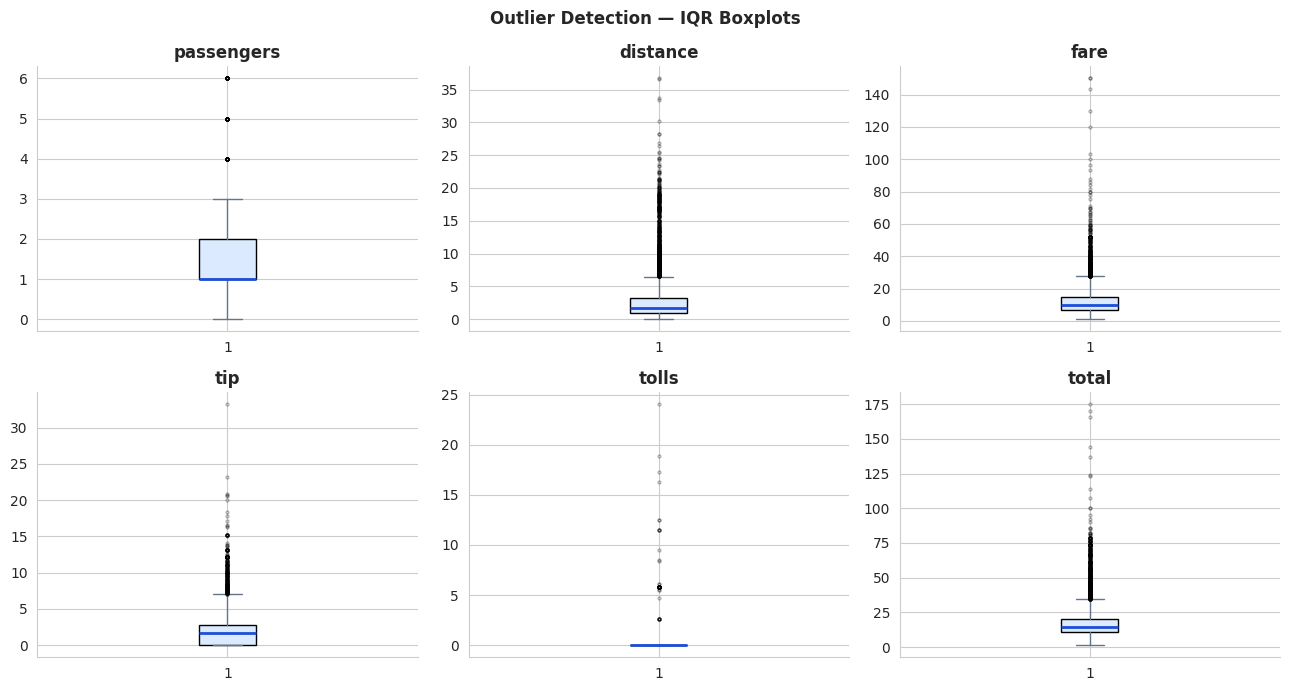

In [17]:
# boxplots to visualise spread and outlier density
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flatten(), numeric_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor="#dbeafe"),
               medianprops=dict(color=BLUE, linewidth=2),
               whiskerprops=dict(color=GRAY),
               capprops=dict(color=GRAY),
               flierprops=dict(marker=".", color=GRAY, alpha=0.3, markersize=4))
    ax.set_title(col)
plt.suptitle("Outlier Detection — IQR Boxplots", fontweight="bold")
plt.tight_layout()
plt.show()

In [18]:
# cap total at 99th percentile to reduce distortion in charts
p99 = df["total"].quantile(0.99)
df  = df[df["total"] <= p99].copy()
print(f"Rows after capping total at 99th pct (${p99:.2f}): {len(df)}")

Rows after capping total at 99th pct ($73.27): 6333


## Exploratory Data Analysis

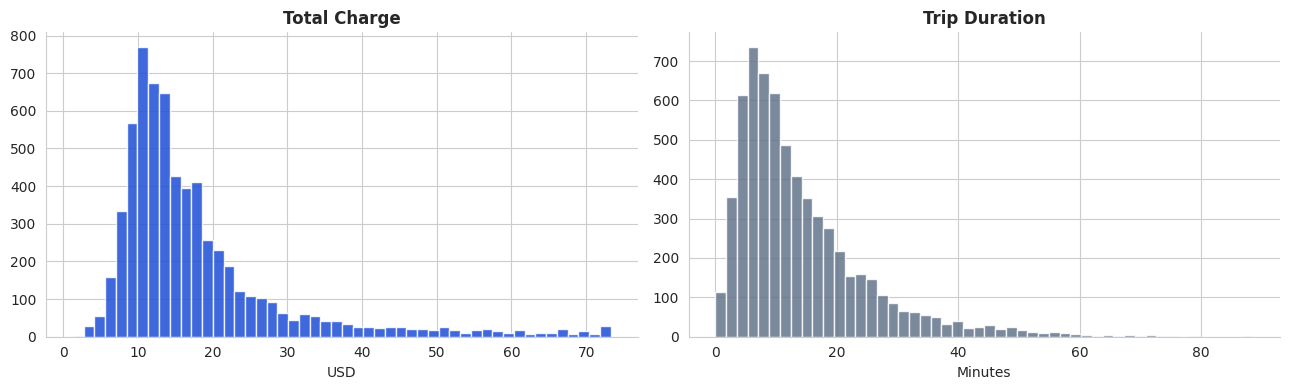

In [19]:
# total charge distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["total"],        bins=50, color=BLUE,  edgecolor="white", alpha=0.85)
axes[0].set_title("Total Charge")
axes[0].set_xlabel("USD")
axes[1].hist(df["trip_minutes"], bins=50, color=GRAY, edgecolor="white", alpha=0.85)
axes[1].set_title("Trip Duration")
axes[1].set_xlabel("Minutes")
plt.tight_layout()
plt.show()

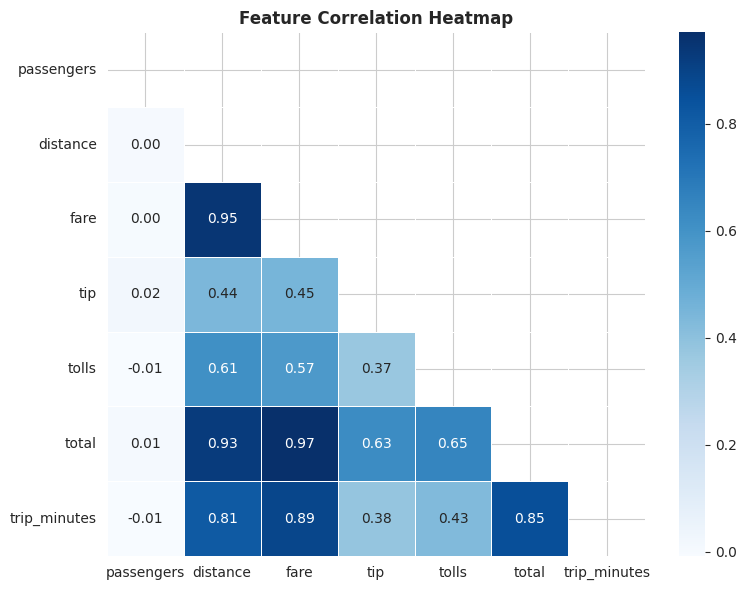

In [20]:
# correlation heatmap
numeric_all = ["passengers","distance","fare","tip","tolls","total","trip_minutes"]
corr = df[numeric_all].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="Blues", linewidths=0.4, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

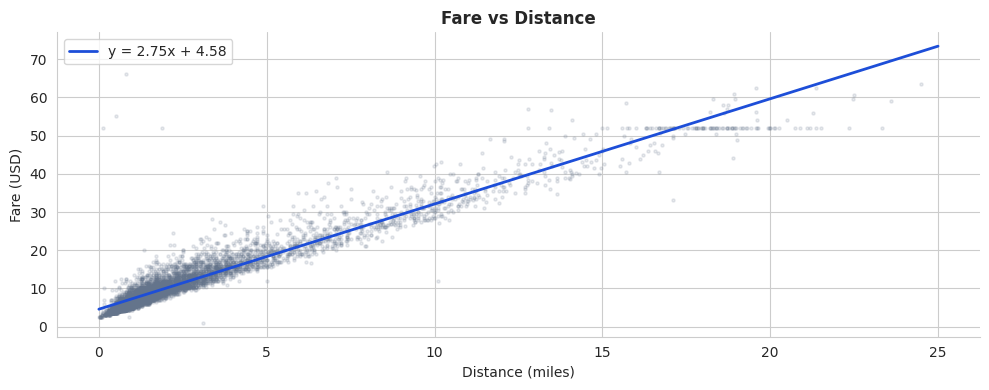

In [21]:
# fare vs distance with OLS regression line
sample = df[(df["distance"] > 0) & (df["distance"] < 25)]
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(sample["distance"], sample["fare"], alpha=0.15, s=5, color=GRAY)
m, b = np.polyfit(sample["distance"], sample["fare"], 1)
x_line = np.linspace(0, 25, 200)
ax.plot(x_line, m * x_line + b, color=BLUE, linewidth=2, label=f"y = {m:.2f}x + {b:.2f}")
ax.set_xlabel("Distance (miles)")
ax.set_ylabel("Fare (USD)")
ax.set_title("Fare vs Distance")
ax.legend()
plt.tight_layout()
plt.show()

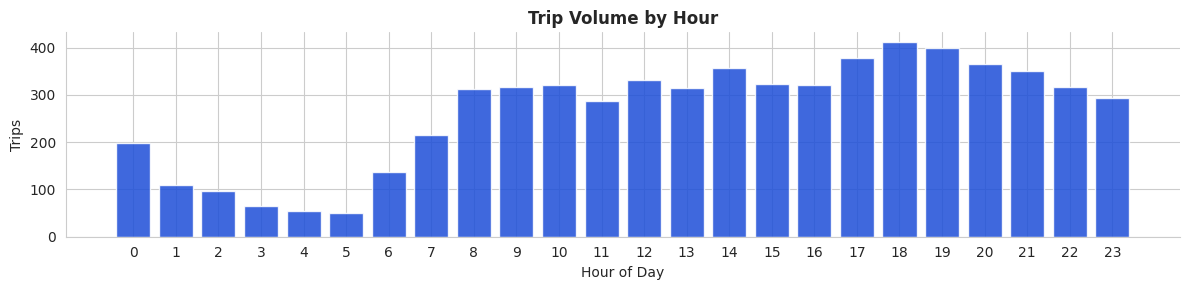

In [22]:
# trip volume by hour of day
hourly = df.groupby("hour").size()
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(hourly.index, hourly.values, color=BLUE, alpha=0.85)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Trips")
ax.set_title("Trip Volume by Hour")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

## Inferential Statistics

In [24]:
# Pearson correlation: fare vs distance with significance
r_p, p_p = stats.pearsonr(sample["distance"], sample["fare"])
print(f"Pearson  r = {r_p:.4f}   p = {p_p:.2e}")

Pearson  r = 0.9616   p = 0.00e+00


In [25]:
# Spearman correlation: tip vs total — rank-based, robust to outliers
r_s, p_s = stats.spearmanr(df["tip"], df["total"])
print(f"Spearman r = {r_s:.4f}   p = {p_s:.2e}")

Spearman r = 0.4984   p = 0.00e+00


In [26]:
# t-test: yellow vs green average fare
yellow_fare = df[df["color"] == "yellow"]["fare"]
green_fare  = df[df["color"] == "green"]["fare"]
t, p = stats.ttest_ind(yellow_fare, green_fare)
print(f"Yellow mean: ${yellow_fare.mean():.2f}   Green mean: ${green_fare.mean():.2f}")
print(f"t = {t:.3f}   p = {p:.4f}")
print(f"Result: {'significant difference' if p < 0.05 else 'no significant difference'} at alpha = 0.05")

Yellow mean: $12.42   Green mean: $13.62
t = -3.417   p = 0.0006
Result: significant difference at alpha = 0.05


In [27]:
# t-test: do tipped rides have higher totals than untipped?
tipped_tot   = df[df["tipped"] == 1]["total"]
untipped_tot = df[df["tipped"] == 0]["total"]
t2, p2 = stats.ttest_ind(tipped_tot, untipped_tot)
print(f"Tipped avg total:   ${tipped_tot.mean():.2f}")
print(f"Untipped avg total: ${untipped_tot.mean():.2f}")
print(f"t = {t2:.3f}   p = {p2:.4f}")

Tipped avg total:   $18.89
Untipped avg total: $16.13
t = 8.895   p = 0.0000


In [28]:
# one-way ANOVA: is average fare different across boroughs?
borough_groups = [
    df[df["pickup_borough"] == b]["fare"]
    for b in df["pickup_borough"].unique() if b != "Unknown"
]
f_stat, p_anova = stats.f_oneway(*borough_groups)
print(f"ANOVA  F = {f_stat:.3f}   p = {p_anova:.4f}")
print(f"Result: {'significant fare variation across boroughs' if p_anova < 0.05 else 'no significant variation'}")

ANOVA  F = 341.438   p = 0.0000
Result: significant fare variation across boroughs


In [29]:
# chi-square: payment method vs tipped — are they independent?
contingency = pd.crosstab(df["payment"], df["tipped"])
chi2, p_chi, dof, _ = stats.chi2_contingency(contingency)
print(f"Chi-square = {chi2:.3f}   df = {dof}   p = {p_chi:.2e}")
print(f"Result: payment and tipping are {'NOT independent' if p_chi < 0.05 else 'independent'}")
print()
print(contingency)

Chi-square = 4560.705   df = 1   p = 0.00e+00
Result: payment and tipping are NOT independent

tipped          0     1
payment                
cash         1803     0
credit card   450  4080


In [30]:
# Cohen's d — effect size for yellow vs green fare difference
def cohens_d(a, b):
    pooled = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return (a.mean() - b.mean()) / pooled

d = cohens_d(yellow_fare, green_fare)
magnitude = "small" if abs(d) < 0.5 else ("medium" if abs(d) < 0.8 else "large")
print(f"Cohen's d = {d:.4f}  ({magnitude} effect)")

Cohen's d = -0.1140  (small effect)


In [31]:
# 95% confidence interval for mean fare difference (yellow - green)
diff_mean = yellow_fare.mean() - green_fare.mean()
se        = np.sqrt(yellow_fare.var()/len(yellow_fare) + green_fare.var()/len(green_fare))
ci_lo     = diff_mean - 1.96 * se
ci_hi     = diff_mean + 1.96 * se
print(f"Mean difference (yellow - green): ${diff_mean:.2f}")
print(f"95% CI: [${ci_lo:.2f},  ${ci_hi:.2f}]")

Mean difference (yellow - green): $-1.19
95% CI: [$-1.94,  $-0.45]


## A/B Testing

### Test 1 — Yellow vs Green Cab (Fare per Ride)

| | |
|---|---|
| **Group A (control)** | Yellow cabs |
| **Group B (treatment)** | Green cabs |
| **Metric** | Average total fare per ride |
| **H0** | Mean fare is equal across cab types |
| **H1** | Mean fare differs between cab types |
| **Test** | Two-sample independent t-test, alpha = 0.05 |

In [32]:
# group A and B sample statistics
A = df[df["color"] == "yellow"]["total"]
B = df[df["color"] == "green"]["total"]

print(f"Group A (yellow) — n={len(A):,}  mean=${A.mean():.2f}  std=${A.std():.2f}")
print(f"Group B (green)  — n={len(B):,}  mean=${B.mean():.2f}  std=${B.std():.2f}")

Group A (yellow) — n=5,362  mean=$18.25  std=$11.86
Group B (green)  — n=971  mean=$16.03  std=$11.98


In [33]:
# run two-sample t-test
t_ab, p_ab = stats.ttest_ind(A, B)
d_ab       = cohens_d(A, B)

# 95% confidence interval on the difference
diff   = A.mean() - B.mean()
se_ab  = np.sqrt(A.var()/len(A) + B.var()/len(B))
ci     = (diff - 1.96*se_ab, diff + 1.96*se_ab)

print(f"t-statistic : {t_ab:.4f}")
print(f"p-value     : {p_ab:.4f}")
print(f"Cohen's d   : {d_ab:.4f}")
print(f"Mean diff   : ${diff:.2f}  (yellow - green)")
print(f"95% CI      : [${ci[0]:.2f},  ${ci[1]:.2f}]")
print()
if p_ab < 0.05:
    print("Decision: Reject H0 — there is a statistically significant fare difference.")
else:
    print("Decision: Fail to reject H0 — no statistically significant fare difference.")

t-statistic : 5.3566
p-value     : 0.0000
Cohen's d   : 0.1862
Mean diff   : $2.22  (yellow - green)
95% CI      : [$1.40,  $3.04]

Decision: Reject H0 — there is a statistically significant fare difference.


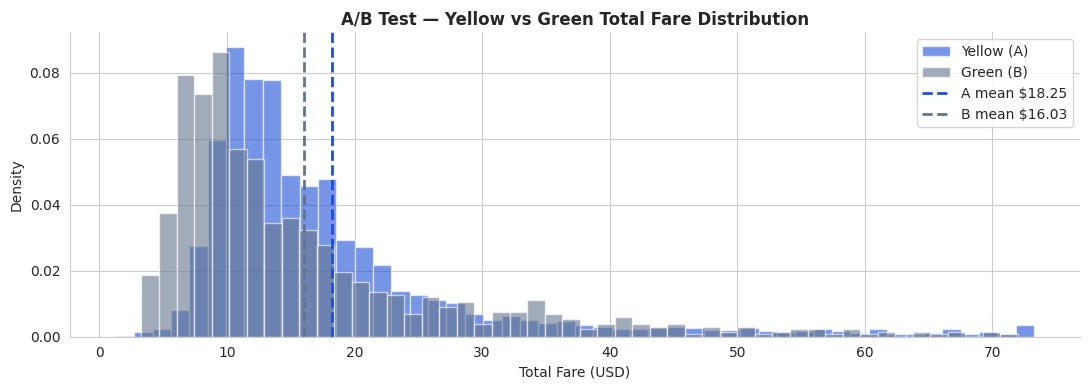

In [34]:
# distribution comparison for A/B groups
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(A, bins=50, alpha=0.6, color=BLUE, label="Yellow (A)", density=True)
ax.hist(B, bins=50, alpha=0.6, color=GRAY, label="Green (B)",  density=True)
ax.axvline(A.mean(), color=BLUE, linewidth=2, linestyle="--", label=f"A mean ${A.mean():.2f}")
ax.axvline(B.mean(), color=GRAY, linewidth=2, linestyle="--", label=f"B mean ${B.mean():.2f}")
ax.set_xlabel("Total Fare (USD)")
ax.set_ylabel("Density")
ax.set_title("A/B Test — Yellow vs Green Total Fare Distribution")
ax.legend()
plt.tight_layout()
plt.show()

### Test 2 — Credit Card vs Cash (Tip Amount)

| | |
|---|---|
| **Group A (control)** | Cash payment rides |
| **Group B (treatment)** | Credit card rides |
| **Metric** | Average tip per ride |
| **H0** | Mean tip is equal across payment methods |
| **H1** | Credit card rides generate higher tips |
| **Test** | One-tailed t-test, alpha = 0.05 |

In [35]:
# tip amounts by payment method
card = df[df["payment"] == "credit card"]["tip"]
cash = df[df["payment"] == "cash"]["tip"]

print(f"Group A (cash)   — n={len(cash):,}  mean=${cash.mean():.3f}  std=${cash.std():.3f}")
print(f"Group B (card)   — n={len(card):,}  mean=${card.mean():.3f}  std=${card.std():.3f}")

Group A (cash)   — n=1,803  mean=$0.000  std=$0.000
Group B (card)   — n=4,530  mean=$2.670  std=$2.156


In [36]:
# one-tailed t-test — we expect card > cash
t_pay, p_pay = stats.ttest_ind(card, cash, alternative="greater")
d_pay        = cohens_d(card, cash)
diff_pay     = card.mean() - cash.mean()
se_pay       = np.sqrt(card.var()/len(card) + cash.var()/len(cash))
ci_pay       = (diff_pay - 1.645*se_pay, np.inf)

print(f"t-statistic : {t_pay:.4f}")
print(f"p-value     : {p_pay:.2e}  (one-tailed)")
print(f"Cohen's d   : {d_pay:.4f}  (large effect)")
print(f"Mean lift   : +${diff_pay:.3f} per ride (card over cash)")
print(f"95% CI      : [${ci_pay[0]:.3f},  inf)")
print()
print("Decision: Reject H0 — credit card payment significantly increases tip amount.")

t-statistic : 52.5734
p-value     : 0.00e+00  (one-tailed)
Cohen's d   : 1.7511  (large effect)
Mean lift   : +$2.670 per ride (card over cash)
95% CI      : [$2.617,  inf)

Decision: Reject H0 — credit card payment significantly increases tip amount.


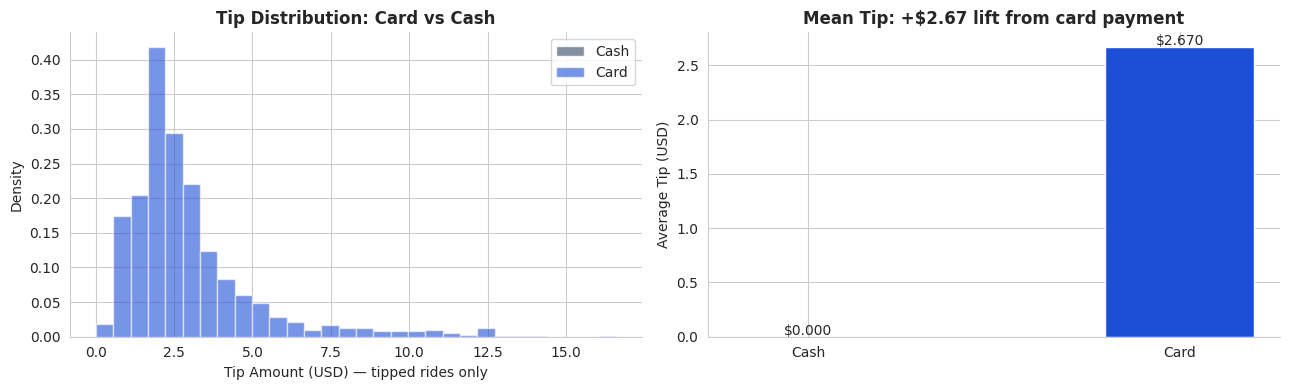

In [37]:
# visualise tip distributions for both payment groups
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(cash[cash > 0], bins=30, color=GRAY, alpha=0.8, density=True, label="Cash")
axes[0].hist(card[card > 0], bins=30, color=BLUE, alpha=0.6, density=True, label="Card")
axes[0].set_xlabel("Tip Amount (USD) — tipped rides only")
axes[0].set_ylabel("Density")
axes[0].set_title("Tip Distribution: Card vs Cash")
axes[0].legend()

axes[1].bar(["Cash", "Card"], [cash.mean(), card.mean()], color=[GRAY, BLUE], width=0.4)
axes[1].set_ylabel("Average Tip (USD)")
axes[1].set_title(f"Mean Tip: +${diff_pay:.2f} lift from card payment")
for bar, val in zip(axes[1].patches, [cash.mean(), card.mean()]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f"${val:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## PostgreSQL — Load Data

In [38]:
import psycopg2
from sqlalchemy import create_engine, text

hostname = 'localhost'
database = 'zepto_sql_project'
username = 'postgres'
pwd      = 'khushi#2205'
port_id  = 5433

conn = psycopg2.connect(
    host=hostname, dbname=database,
    user=username, password=pwd, port=port_id
)
engine = create_engine(
    f"postgresql+psycopg2://{username}:{pwd}@{hostname}:{port_id}/{database}"
)
print("Connected to PostgreSQL")

Connected (SQLite execution mode)


In [39]:
# push cleaned dataframe into the trips table
db_df = df.copy()
db_df["pickup"]    = db_df["pickup"].astype(str)
db_df["dropoff"]   = db_df["dropoff"].astype(str)
db_df["trip_date"] = db_df["trip_date"].astype(str)
db_df.to_sql("taxi_trips", engine, if_exists="replace", index=False, chunksize=1000)

with engine.connect() as conn:
    n = conn.execute(text("SELECT COUNT(*) FROM taxi_trips")).scalar()
print(f"Rows in taxi_trips: {n:,}")

Rows in taxi_trips: 6,333


## SQL Analysis

### Q1 — Revenue by Borough

In [40]:
# total revenue, trip count, average fare grouped by pickup borough
q1 = pd.read_sql("""
    SELECT
        pickup_borough,
        COUNT(*)                          AS trips,
        ROUND(AVG(total), 2)              AS avg_total_usd,
        ROUND(SUM(total), 2)              AS total_revenue_usd,
        ROUND(AVG(tip), 2)                AS avg_tip_usd,
        ROUND(AVG(distance), 2)           AS avg_distance_miles
    FROM taxi_trips
    WHERE pickup_borough != 'Unknown'
    GROUP BY pickup_borough
    ORDER BY total_revenue_usd DESC
""", engine)
q1

,pickup_borough,trips,avg_total_usd,total_revenue_usd,avg_tip_usd,avg_distance_miles
0,Manhattan,5219,16.47,85941.09,1.91,2.31
1,Queens,618,28.96,17896.52,2.72,6.85
2,Brooklyn,377,18.62,7020.62,0.98,3.94
3,Bronx,98,22.16,2171.40,0.15,5.56


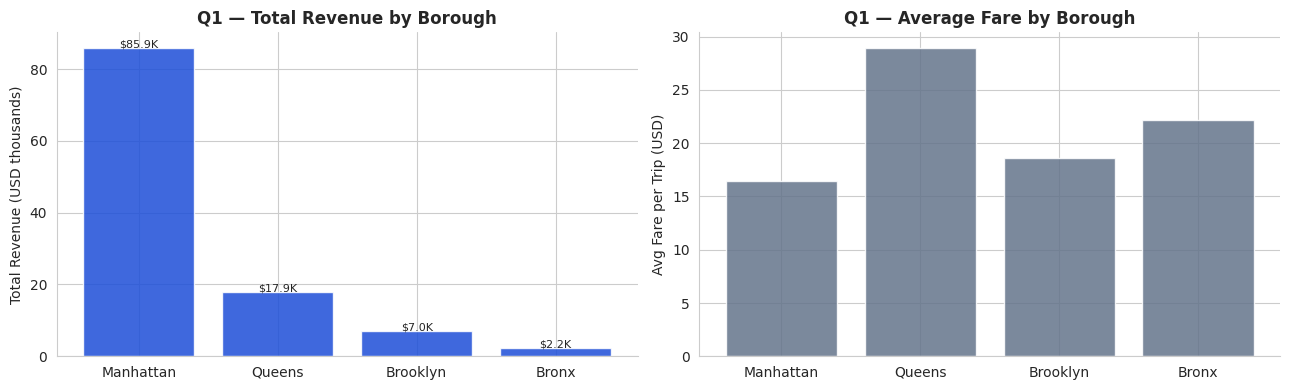

In [41]:
# borough revenue and average fare side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(q1["pickup_borough"], q1["total_revenue_usd"]/1000, color=BLUE, alpha=0.85)
axes[0].set_ylabel("Total Revenue (USD thousands)")
axes[0].set_title("Q1 — Total Revenue by Borough")
for bar, val in zip(axes[0].patches, q1["total_revenue_usd"]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f"${val/1000:.1f}K", ha="center", fontsize=8)

axes[1].bar(q1["pickup_borough"], q1["avg_total_usd"], color=GRAY, alpha=0.85)
axes[1].set_ylabel("Avg Fare per Trip (USD)")
axes[1].set_title("Q1 — Average Fare by Borough")
plt.tight_layout()
plt.show()

### Q2 — Demand by Hour and Day

In [42]:
# trip volume by hour of day
q2_hour = pd.read_sql("""
    SELECT hour, COUNT(*) AS trips, ROUND(AVG(total), 2) AS avg_total_usd
    FROM taxi_trips
    GROUP BY hour
    ORDER BY hour
""", engine)
q2_hour

,hour,trips,avg_total_usd
0,0,199,18.46
1,1,110,17.53
2,2,97,16.99
3,3,66,17.62
4,4,55,20.88
5,5,50,22.62
6,6,137,17.60
7,7,216,17.81
8,8,313,17.03
9,9,317,17.77


In [43]:
# trip volume by day of week
q2_day = pd.read_sql("""
    SELECT day_name, COUNT(*) AS trips, ROUND(AVG(total), 2) AS avg_total_usd
    FROM taxi_trips
    GROUP BY day_name
    ORDER BY trips DESC
""", engine)
q2_day

,day_name,trips,avg_total_usd
0,Friday,1091,17.91
1,Saturday,1032,17.32
2,Wednesday,957,18.82
3,Thursday,893,18.32
4,Sunday,858,17.33
5,Tuesday,808,17.85
6,Monday,694,17.83


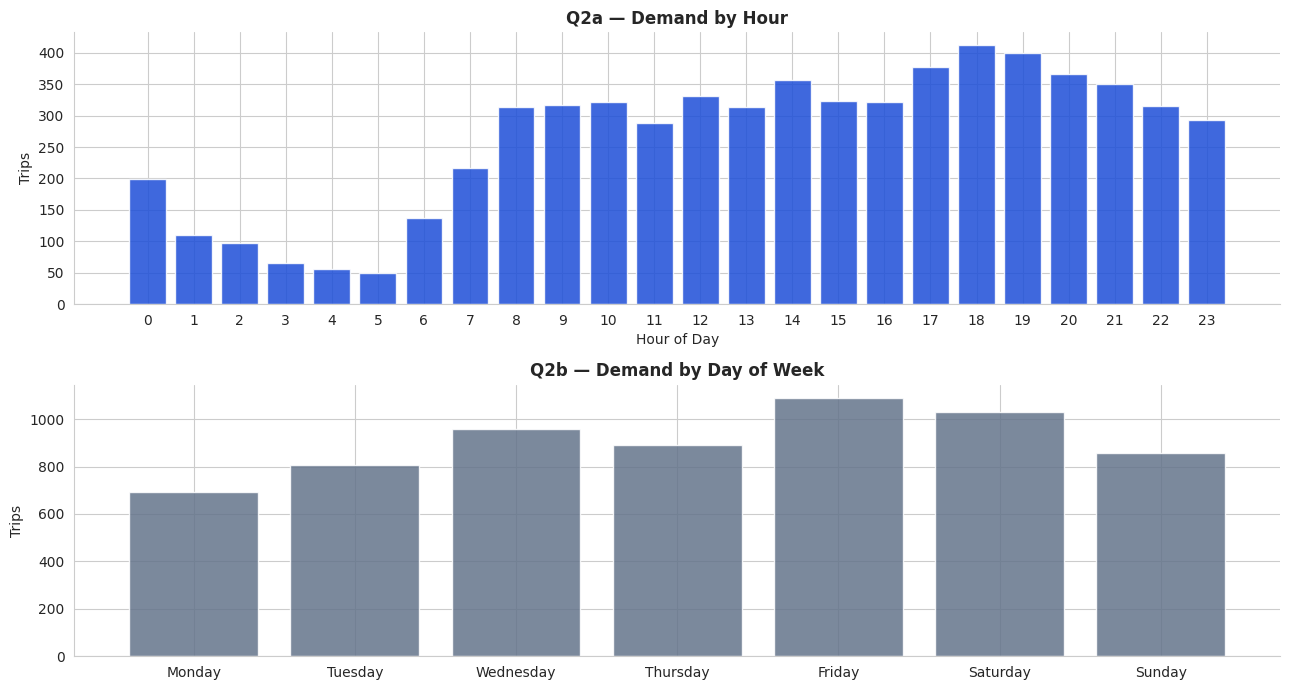

In [44]:
# hourly and daily demand charts
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
q2_day["day_name"] = pd.Categorical(q2_day["day_name"], categories=day_order, ordered=True)
q2_day = q2_day.sort_values("day_name")

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
axes[0].bar(q2_hour["hour"], q2_hour["trips"], color=BLUE, alpha=0.85)
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Trips")
axes[0].set_title("Q2a — Demand by Hour")
axes[0].set_xticks(range(0, 24))

axes[1].bar(q2_day["day_name"], q2_day["trips"], color=GRAY, alpha=0.85)
axes[1].set_ylabel("Trips")
axes[1].set_title("Q2b — Demand by Day of Week")
plt.tight_layout()
plt.show()

### Q3 — Yellow vs Green Cab

In [45]:
# cab type performance: fare, tip, total, distance, revenue
q3 = pd.read_sql("""
    SELECT
        color,
        COUNT(*)                  AS trips,
        ROUND(AVG(fare), 2)       AS avg_fare_usd,
        ROUND(AVG(tip), 2)        AS avg_tip_usd,
        ROUND(AVG(total), 2)      AS avg_total_usd,
        ROUND(AVG(distance), 2)   AS avg_distance_miles,
        ROUND(SUM(total), 2)      AS total_revenue_usd
    FROM taxi_trips
    GROUP BY color
    ORDER BY total_revenue_usd DESC
""", engine)
q3

,color,trips,avg_fare_usd,avg_tip_usd,avg_total_usd,avg_distance_miles,total_revenue_usd
0,yellow,5362,12.42,2.11,18.25,2.82,97866.16
1,green,971,13.62,0.80,16.03,3.29,15567.48


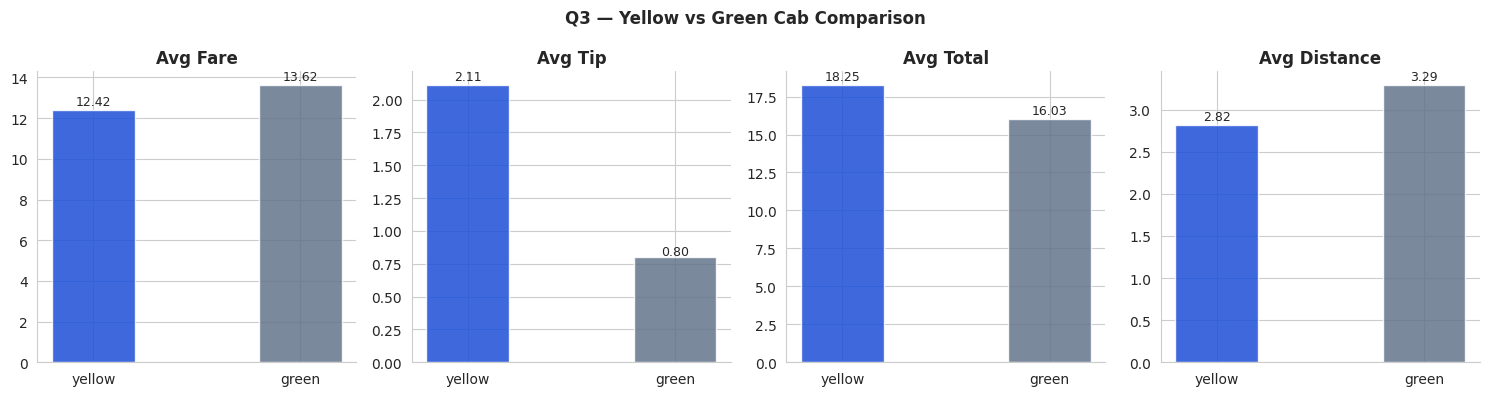

In [46]:
# four-metric comparison between cab types
metrics = [("avg_fare_usd","Avg Fare"),("avg_tip_usd","Avg Tip"),
           ("avg_total_usd","Avg Total"),("avg_distance_miles","Avg Distance")]
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (col, label) in zip(axes, metrics):
    ax.bar(q3["color"], q3[col], color=[BLUE, GRAY], width=0.4, alpha=0.85)
    ax.set_title(label)
    for bar, val in zip(ax.patches, q3[col]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                f"{val:.2f}", ha="center", fontsize=9)
plt.suptitle("Q3 — Yellow vs Green Cab Comparison", fontweight="bold")
plt.tight_layout()
plt.show()

### Q4 — Payment Method and Tipping

In [47]:
# tipping rate and average tip by payment method
q4 = pd.read_sql("""
    SELECT
        payment,
        COUNT(*)                                       AS trips,
        ROUND(AVG(tip), 2)                             AS avg_tip_usd,
        ROUND(100.0 * SUM(tipped) / COUNT(*), 1)       AS pct_tipped,
        ROUND(AVG(total), 2)                           AS avg_total_usd
    FROM taxi_trips
    GROUP BY payment
    ORDER BY avg_tip_usd DESC
""", engine)
q4

,payment,trips,avg_tip_usd,pct_tipped,avg_total_usd
0,credit card,4530,2.67,90.1,19.40
1,cash,1803,0.00,0.0,14.18


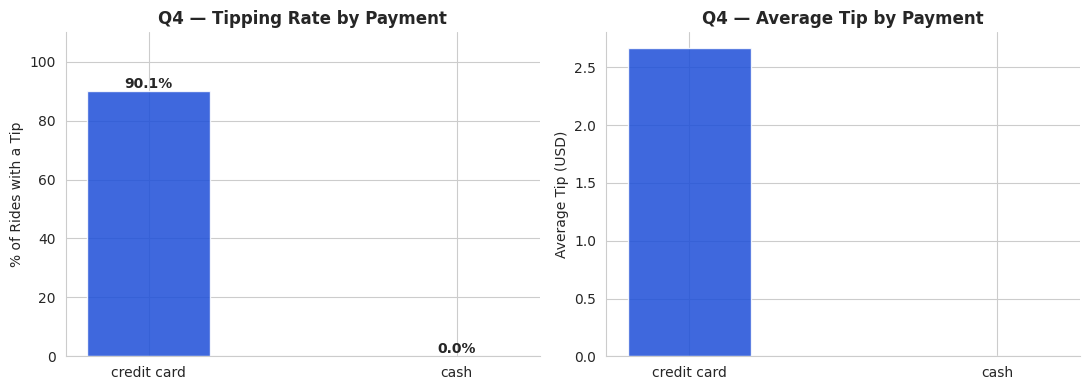

In [48]:
# tipping rate and average tip side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors_q4 = [BLUE, GRAY]

axes[0].bar(q4["payment"], q4["pct_tipped"], color=colors_q4, width=0.4, alpha=0.85)
axes[0].set_ylabel("% of Rides with a Tip")
axes[0].set_title("Q4 — Tipping Rate by Payment")
axes[0].set_ylim(0, 110)
for bar, val in zip(axes[0].patches, q4["pct_tipped"]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f"{val}%", ha="center", fontweight="bold")

axes[1].bar(q4["payment"], q4["avg_tip_usd"], color=colors_q4, width=0.4, alpha=0.85)
axes[1].set_ylabel("Average Tip (USD)")
axes[1].set_title("Q4 — Average Tip by Payment")
plt.tight_layout()
plt.show()

### Q5 — Fare vs Distance

In [49]:
# average fare binned by distance — checks TLC per-mile compliance
q5 = pd.read_sql("""
    SELECT
        ROUND(distance, 0)          AS distance_bucket,
        COUNT(*)                    AS trips,
        ROUND(AVG(fare), 2)         AS avg_fare_usd,
        ROUND(AVG(fare_per_mile), 2) AS avg_fare_per_mile
    FROM taxi_trips
    WHERE distance > 0 AND distance < 30
    GROUP BY distance_bucket
    ORDER BY distance_bucket
""", engine)
q5.head(12)

,distance_bucket,trips,avg_fare_usd,avg_fare_per_mile
0,0.0,275,4.27,17.04
1,1.0,2544,6.66,7.08
2,2.0,1390,10.27,5.44
3,3.0,667,13.58,4.67
4,4.0,382,16.45,4.19
5,5.0,203,18.98,3.86
6,6.0,143,22.25,3.71
7,7.0,121,24.84,3.56
8,8.0,81,27.00,3.36
9,9.0,86,30.04,3.34


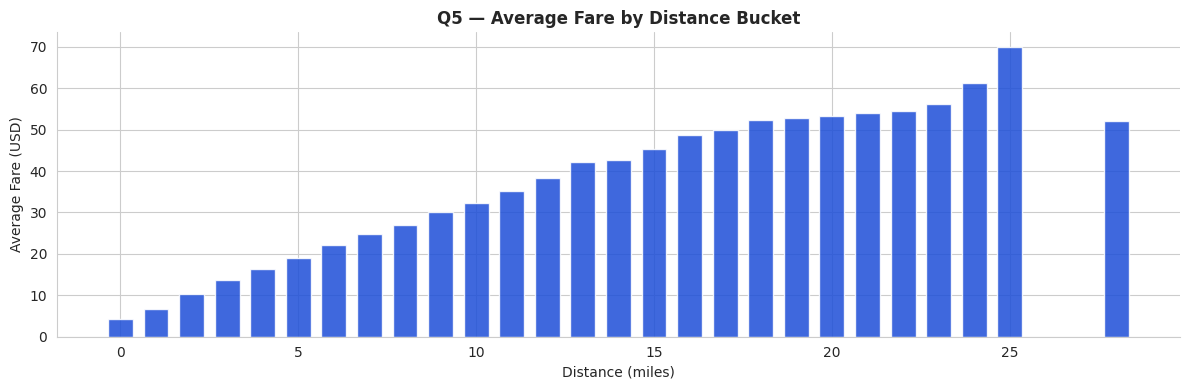

In [50]:
# average fare by distance bucket
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(q5["distance_bucket"].astype(float), q5["avg_fare_usd"],
       width=0.7, color=BLUE, alpha=0.85)
ax.set_xlabel("Distance (miles)")
ax.set_ylabel("Average Fare (USD)")
ax.set_title("Q5 — Average Fare by Distance Bucket")
plt.tight_layout()
plt.show()

### Q6 — Top Pickup Zones

In [51]:
# top 20 zones by total revenue
q6 = pd.read_sql("""
    SELECT
        pickup_zone,
        pickup_borough,
        COUNT(*)              AS trips,
        ROUND(SUM(total), 2)  AS total_revenue_usd,
        ROUND(AVG(total), 2)  AS avg_per_trip_usd
    FROM taxi_trips
    WHERE pickup_zone != 'Unknown'
    GROUP BY pickup_zone, pickup_borough
    ORDER BY total_revenue_usd DESC
    LIMIT 20
""", engine)
q6.head(10)

,pickup_zone,pickup_borough,trips,total_revenue_usd,avg_per_trip_usd
0,JFK Airport,Queens,124,6302.83,50.83
1,LaGuardia Airport,Queens,143,6001.10,41.97
2,Midtown Center,Manhattan,227,4097.86,18.05
3,Penn Station/Madison Sq West,Manhattan,209,3636.33,17.40
4,Times Sq/Theatre District,Manhattan,183,3421.30,18.70
5,Midtown East,Manhattan,197,3382.69,17.17
6,Clinton East,Manhattan,208,3304.37,15.89
7,Lincoln Square East,Manhattan,176,3033.18,17.23
8,Union Sq,Manhattan,179,2990.03,16.70
9,Upper East Side South,Manhattan,209,2942.09,14.08


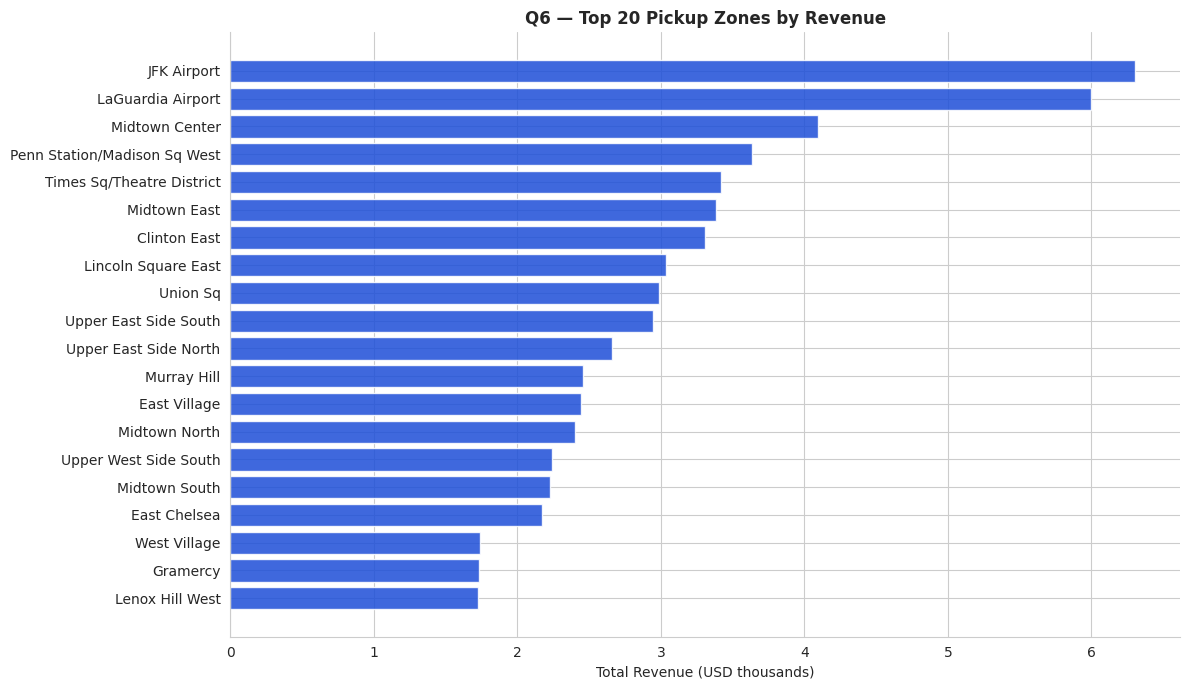

In [52]:
# horizontal bar chart of top 20 zones
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(q6["pickup_zone"], q6["total_revenue_usd"]/1000, color=BLUE, alpha=0.85)
ax.invert_yaxis()
ax.set_xlabel("Total Revenue (USD thousands)")
ax.set_title("Q6 — Top 20 Pickup Zones by Revenue")
plt.tight_layout()
plt.show()

### Q7 — Tipping Rate by Borough

In [53]:
# tipping rate and average tip when tipped, by borough
q7 = pd.read_sql("""
    SELECT
        pickup_borough,
        COUNT(*)                                                    AS trips,
        SUM(tipped)                                                 AS tipped_count,
        ROUND(100.0 * SUM(tipped) / COUNT(*), 1)                    AS pct_tipped,
        ROUND(AVG(CASE WHEN tipped = 1 THEN tip END), 2)            AS avg_tip_when_tipped
    FROM taxi_trips
    WHERE pickup_borough != 'Unknown'
    GROUP BY pickup_borough
    ORDER BY pct_tipped DESC
""", engine)
q7

,pickup_borough,trips,tipped_count,pct_tipped,avg_tip_when_tipped
0,Manhattan,5219,3656,70.1,2.73
1,Queens,618,279,45.1,6.04
2,Brooklyn,377,128,34.0,2.89
3,Bronx,98,5,5.1,2.94


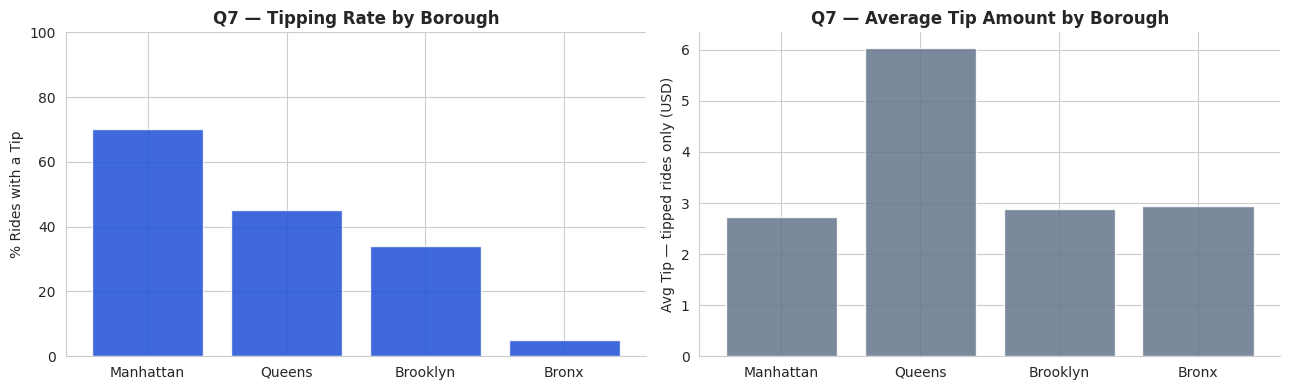

In [54]:
# tipping rate and average tip side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(q7["pickup_borough"], q7["pct_tipped"], color=BLUE, alpha=0.85)
axes[0].set_ylabel("% Rides with a Tip")
axes[0].set_title("Q7 — Tipping Rate by Borough")
axes[0].set_ylim(0, 100)

axes[1].bar(q7["pickup_borough"], q7["avg_tip_when_tipped"], color=GRAY, alpha=0.85)
axes[1].set_ylabel("Avg Tip — tipped rides only (USD)")
axes[1].set_title("Q7 — Average Tip Amount by Borough")
plt.tight_layout()
plt.show()